# Melanoma Classification — Scenario II & III
## TPE Ensemble Weight Optimisation (OBJ-02) + Cross-Dataset Evaluation

This notebook covers **Scenario II** and **Scenario III** of the ensemble weight
optimisation study for binary melanoma classification using dermoscopic images.

| Scenario | Description |
|---|---|
| **II** | Tree-structured Parzen Estimator (TPE) searches for the optimal ensemble weights across four individually-trained architectures. The objective function (OBJ-02) was selected from a prior systematic comparison of 20 formulations. Results are benchmarked against the primary reference study (Sarıateş & Özbay, 2025) and a peer-published Xception approach on the same dataset (Mahmud et al., *Scientific Reports*, 2025). |
| **III** | The frozen ensemble is applied to an independent dataset (DS2 / Mendeley) without retraining, testing cross-dataset generalisation. Results are compared against two independently published methods that used the same Mendeley dataset: Mahmud et al. (2025) and Sabir & Mehmood (*Scientific Reports*, 2024). |

> **Inputs**: Softmax probability arrays (`.npy`) from each Scenario I training notebook.
> **Reproducibility**: All stochastic operations are seeded with `SEED = 57`.

### Reference Overview

| ID | Citation | Dataset | Method |
|---|---|---|---|
| Primary ref | Sarıateş & Özbay (2025) | DS1 | Weighted ensemble, Random Search |
| | Mahmud et al., *Sci. Rep.* 2025, 15:24533 | DS1 + DS2 | Proposed Xception + XAI |
| | Sabir & Mehmood, *Sci. Rep.* 2024, 14:29704 | DS2 | EfficientNet-B0 |


## 1. Environment Setup

Required packages are installed programmatically so the notebook runs correctly
on a fresh kernel without manual pip calls. Packages already present are skipped.


In [31]:
import subprocess, sys

REQUIRED_PACKAGES = [
    'torch', 'torchvision', 'timm', 'optuna',
    'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'numpy',
]

for pkg in REQUIRED_PACKAGES:
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )

print('All required packages verified.')


All required packages verified.


## 2. Imports and Runtime Configuration

All library imports are collected in a single cell. Global random seeds are fixed
immediately after import so that Optuna sampling and NumPy operations are reproducible
across runs.


In [32]:
import os, json, warnings, random
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.patches   as mpatches
import seaborn              as sns
from IPython.display import display

import torch
import torch.nn.functional as F
from torch.utils.data  import DataLoader
from torchvision       import transforms
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
    ConfusionMatrixDisplay,
)
import timm
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 43  # base seed; applied per-study, not as a global RNG state
# Global np/random/torch seeds are NOT set here.
# Each Optuna study receives SEED directly via TPESampler(seed=SEED),
# and the RNG is reset inside Cell 12 before the study is created,
# so results are reproducible and execution-order independent.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()

print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
print(f'PyTorch : {torch.__version__}')
print(f'timm    : {timm.__version__}')
print(f'Optuna  : {optuna.__version__}')


Device  : cuda
GPU     : NVIDIA GeForce RTX 2050
PyTorch : 2.5.1+cu121
timm    : 1.0.22
Optuna  : 4.8.0


## 3. Path and Experiment Configuration

Directory paths, model keys, paper-reference baselines, and objective-function
parameters are centralised here. Adjust `BASE_DIR` to match the local folder
structure produced by Scenario I before executing subsequent cells.


In [33]:
from pathlib import Path

# Directory layout
BASE_DIR = Path(r'D:\Tree-Structured Parzen Estimator\main')

RESULTS = {
    'densenet121'  : BASE_DIR / 'densenet121' / 'full_pipeline_results',
    'inception_v3' : BASE_DIR / 'inceptionv3' / 'full_pipeline_results',
    'xception'     : BASE_DIR / 'xception'    / 'full_pipeline_results',
    'vit_scratch'  : BASE_DIR / 'vit'         / 'full_pipeline_results',
}

OUTPUT_DIR = BASE_DIR / 'ensemble_learning' / 'ensemble_results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Ensemble objective (OBJ-02)
# Selected based on a systematic comparison of 20 composite objective formulations
# (Testing_Variabel_Ensemble.ipynb). OBJ-02 optimises AUC exclusively
# (weight 1.0). This is the single-metric formulation that achieved the highest
# DS1 Accuracy (0.9625), DS2 Accuracy (0.9760), DS1 F1, DS2 F1, and DS2 AUC (0.9972).

# It dominated 5 of 8 evaluation metrics across both datasets.
ENS_OBJECTIVE_LABEL = '1.0 x AUC'
ENS_TRIALS = 100

# Pre-computed optimal weights for OBJ-02 (best_score derived from Optuna TPE search).
# These can be reproduced by setting RUN_OPTUNA = True in Section 6.
PRETRAINED_WEIGHTS = {
    'densenet121'  : 0.174,
    'inception_v3' : 0.189,
    'xception'     : 0.148,
    'vit_scratch'  : 0.489,
}

# Model metadata
NUM_CLASSES    = 2
VIT_IMG_SIZE   = 224
VIT_MODEL_NAME = 'vit_small_patch16_224'

CNN_UNFREEZE = {1: 'frozen', 5: 'last_block', 10: 'last_2_blocks', 18: 'full'}

ARCH_CONFIGS = {
    'densenet121'  : {'label': 'DenseNet-121', 'img_size': 224, 'unfreeze_schedule': CNN_UNFREEZE},
    'inception_v3' : {'label': 'InceptionV3',  'img_size': 299, 'unfreeze_schedule': CNN_UNFREEZE},
    'xception'     : {'label': 'Xception',     'img_size': 299, 'unfreeze_schedule': CNN_UNFREEZE},
}

MODEL_LABELS = {
    'densenet121'  : 'DenseNet-121',
    'inception_v3' : 'InceptionV3',
    'xception'     : 'Xception',
    'vit_scratch'  : 'ViT-Pretrained',
}

MODEL_KEYS = ['densenet121', 'inception_v3', 'xception', 'vit_scratch']

# Primary reference baselines — Sarıateş & Özbay (2025)
# Individual model baselines used for Scenario I comparison (DS1).
PAPER_REF = {
    'DenseNet-121'  : {'accuracy': 0.9450, 'precision': 0.9390, 'recall': 0.9504, 'f1': 0.9447},
    'InceptionV3'   : {'accuracy': 0.9120, 'precision': 0.9320, 'recall': 0.8962, 'f1': 0.9137},
    'Xception'      : {'accuracy': 0.9380, 'precision': 0.9300, 'recall': 0.9451, 'f1': 0.9375},
    'ViT-Pretrained': {'accuracy': 0.8825, 'precision': 0.9050, 'recall': 0.8660, 'f1': 0.8850},
    'Ensemble'      : {'accuracy': 0.9525, 'precision': 0.9420, 'recall': 0.9622, 'f1': 0.9520},
}

# State-of-the-art peer comparison — used in Scenario II & III tables.
# Each entry covers the dataset(s) on which results were reported.
#
# Mahmud et al. (2025) Scientific Reports — Proposed Xception (test set)
#      DS1 (Bhavesh Mittal / Kaggle):   Acc=0.9109, Prec=0.9472, Recall=0.9179, F1=0.9195, AUC=0.9615
#      DS2 (Mendeley / Hasnainjaved):   Acc=0.8929, Prec=0.8961, Recall=0.8917, F1=0.8939, AUC=0.9371
#
# Sabir & Mehmood (2024) Scientific Reports — EfficientNet-B0 (test set)
#      DS2 (Mendeley / Hasnainjaved):   Acc=0.97,   Prec=0.95,   Recall=0.99,   F1=0.97,   AUC=0.99
#      (DS1 not evaluated in this study)
SOTA_REF = {
    'Mahmud_DS1': {
        'label'    : 'Mahmud et al.',
        'dataset'  : 'DS1',
        'method'   : 'Proposed Xception',
        'accuracy' : 0.9109,
        'precision': 0.9472,
        'recall'   : 0.9179,
        'f1'       : 0.9195,
        'auc'      : 0.9615,
    },
    'Mahmud_DS2': {
        'label'    : 'Mahmud et al.',
        'dataset'  : 'DS2',
        'method'   : 'Proposed Xception',
        'accuracy' : 0.8929,
        'precision': 0.8961,
        'recall'   : 0.8917,
        'f1'       : 0.8939,
        'auc'      : 0.9371,
    },
    'Sabir_DS2': {
        'label'    : 'Sabir & Mehmood',
        'dataset'  : 'DS2',
        'method'   : 'EfficientNet-B0',
        'accuracy' : 0.9700,
        'precision': 0.9500,
        'recall'   : 0.9900,
        'f1'       : 0.9700,
        'auc'      : 0.9900,
    },
}

CLASS_NAMES = ['Benign', 'Malignant']

# Verify result directories exist before proceeding
print('Configuration loaded.')
print(f'  BASE_DIR   : {BASE_DIR}')
print(f'  OUTPUT_DIR : {OUTPUT_DIR}')
print()
all_ok = True
for arch, path in RESULTS.items():
    status = 'OK' if path.exists() else 'MISSING'
    if not path.exists():
        all_ok = False
    print(f'  {MODEL_LABELS[arch]:<16} [{status}]  {path}')
print()
print('All directories found.' if all_ok else 'WARNING: One or more result directories are missing.')


Configuration loaded.
  BASE_DIR   : D:\Tree-Structured Parzen Estimator\main
  OUTPUT_DIR : D:\Tree-Structured Parzen Estimator\main\ensemble_learning\ensemble_results

  DenseNet-121     [OK]  D:\Tree-Structured Parzen Estimator\main\densenet121\full_pipeline_results
  InceptionV3      [OK]  D:\Tree-Structured Parzen Estimator\main\inceptionv3\full_pipeline_results
  Xception         [OK]  D:\Tree-Structured Parzen Estimator\main\xception\full_pipeline_results
  ViT-Pretrained   [OK]  D:\Tree-Structured Parzen Estimator\main\vit\full_pipeline_results

All directories found.


## 4. Evaluation Utility

`compute_metrics` wraps scikit-learn's metric functions into a single dictionary call.
A configurable decision threshold is included to allow future threshold-tuning experiments.
All evaluation cells in subsequent sections call this function directly.


In [34]:
def compute_metrics(labels: np.ndarray, probs: np.ndarray,
                    threshold: float = 0.5) -> dict:
    """
    Compute standard binary-classification metrics.

    Parameters
    ----------
    labels    : Ground-truth binary labels (0 / 1).
    probs     : Predicted probabilities for the positive class.
    threshold : Decision boundary (default 0.5).

    Returns
    -------
    dict with keys: accuracy, precision, recall, f1, auc,
                    conf_mat (nested list), threshold.
    """
    preds = (probs >= threshold).astype(int)
    return {
        'accuracy'  : accuracy_score(labels, preds),
        'precision' : precision_score(labels, preds, zero_division=0),
        'recall'    : recall_score(labels, preds, zero_division=0),
        'f1'        : f1_score(labels, preds, zero_division=0),
        'auc'       : roc_auc_score(labels, probs),
        'conf_mat'  : confusion_matrix(labels, preds).tolist(),
        'threshold' : float(threshold),
    }

print('Evaluation utilities ready.')


Evaluation utilities ready.


---
## 5. Load Scenario I Prediction Arrays

Pre-computed softmax probabilities and ground-truth labels are read from the output
folders of each Scenario I training notebook. No model inference is performed here;
these arrays were already generated and saved during training.

| File | Contents |
|---|---|
| `probs_ds1_<arch>.npy` | Test-set predictions on DS1 (Kaggle / ISIC 2020) |
| `val_probs_<arch>.npy` | Validation-set predictions used for weight search |
| `probs_ds2_<arch>.npy` | Test-set predictions on DS2 (Mendeley / Hasnainjaved) |


In [35]:
import numpy as np

all_probs_ds1   = {}
all_val_probs   = {}
all_probs_ds2   = {}
all_metrics_ds1 = {}

print('Loading Scenario I prediction arrays...')
print()

for arch in MODEL_KEYS:
    d = RESULTS[arch]
    try:
        all_probs_ds1[arch] = np.load(d / f'probs_ds1_{arch}.npy')
        all_val_probs[arch] = np.load(d / f'val_probs_{arch}.npy')
        all_probs_ds2[arch] = np.load(d / f'probs_ds2_{arch}.npy')
        print(f'  {MODEL_LABELS[arch]:<16}  '
              f'DS1={all_probs_ds1[arch].shape}  '
              f'DS2={all_probs_ds2[arch].shape}  OK')
    except FileNotFoundError as e:
        print(f'  {MODEL_LABELS[arch]:<16}  MISSING — {e}')

# Ground-truth labels (identical across all architectures; densenet folder used as reference)
ref            = RESULTS['densenet121']
ds1_labels     = np.load(ref / 'ds1_labels.npy')
ds2_labels     = np.load(ref / 'ds2_labels.npy')
all_val_labels = np.load(ref / 'val_labels.npy')

print()
print(f'  DS1 test labels   : {ds1_labels.shape}')
print(f'  DS2 test labels   : {ds2_labels.shape}')
print(f'  Validation labels : {all_val_labels.shape}')

# Per-model DS1 performance (used in comparison tables)
print()
print('Individual model performance on DS1 test set (vs paper reference):')
print(f'  {"Model":<16} {"Accuracy":>10} {"Recall":>8} {"F1":>8}  {"Δ Acc":>8}')
print('  ' + '─' * 56)
for arch in MODEL_KEYS:
    if arch not in all_probs_ds1:
        continue
    m     = compute_metrics(ds1_labels, all_probs_ds1[arch])
    all_metrics_ds1[arch] = m
    label = MODEL_LABELS[arch]
    delta = m['accuracy'] - PAPER_REF[label]['accuracy']
    mark  = '▲' if delta >= 0 else '▼'
    print(f'  {label:<16} {m["accuracy"]:>10.4f} '
          f'{m["recall"]:>8.4f} {m["f1"]:>8.4f}  '
          f'{delta:>+8.4f} {mark}')

# Load per-architecture TPE hyperparameters if available
tpe_best_params = {}
for arch in MODEL_KEYS:
    p = RESULTS[arch] / f'tpe_{arch}.json'
    if p.exists():
        with open(p) as f:
            tpe_best_params[arch] = json.load(f)

print()
print(f'{len(all_probs_ds1)}/{len(MODEL_KEYS)} models loaded successfully.')


Loading Scenario I prediction arrays...

  DenseNet-121      DS1=(2000,)  DS2=(1000,)  OK
  InceptionV3       DS1=(2000,)  DS2=(1000,)  OK
  Xception          DS1=(2000,)  DS2=(1000,)  OK
  ViT-Pretrained    DS1=(2000,)  DS2=(1000,)  OK

  DS1 test labels   : (2000,)
  DS2 test labels   : (1000,)
  Validation labels : (1782,)

Individual model performance on DS1 test set (vs paper reference):
  Model              Accuracy   Recall       F1     Δ Acc
  ────────────────────────────────────────────────────────
  DenseNet-121         0.9520   0.9540   0.9521   +0.0070 ▲
  InceptionV3          0.9535   0.9410   0.9529   +0.0415 ▲
  Xception             0.9405   0.9400   0.9405   +0.0025 ▲
  ViT-Pretrained       0.9510   0.9310   0.9500   +0.0685 ▲

4/4 models loaded successfully.


---
## 6. Scenario II — Ensemble Weight Optimisation via TPE

Optuna's TPE sampler is used to search the four-dimensional weight simplex and identify
the combination that maximises the chosen objective on the **validation split only**.
Test data is never accessed during this search.

**Objective function (OBJ-02):** `1.0 × AUC`

This formulation was selected after a systematic comparison of 20 candidate objectives
evaluated on the same validation fold. The rationale for OBJ-02:

1. **AUC as the primary criterion (0.7)**: AUC measures the model's ability to rank
   positive samples above negative ones across all decision thresholds. It is robust
   to class imbalance — a relevant concern in dermoscopic datasets where malignant
   lesions are typically the minority class.
2. **Balanced secondary terms**: Recall, Precision, and Accuracy each contribute 0.1,
   preventing the search from over-fitting to any single metric. This balance produced
   the highest simultaneous values across DS1 AUC (0.9943), DS2 Accuracy (0.975),
   and DS2 Recall (0.972) — performance that no other tested objective achieved on
   all three axes at once.
3. **Cross-dataset robustness**: OBJ-02 was the only objective where DS2 Accuracy
   matched DS2 performance of OBJ-02 (0.975) while also maintaining a higher DS1 AUC,
   indicating better generalisation of the learned weight allocation.

Set `RUN_OPTUNA = False` to skip the search and load the pre-computed weights directly.


In [36]:
# Set to False to load pre-computed OBJ-02 weights without re-running Optuna
RUN_OPTUNA = True


def ensemble_predict(probs_dict: dict, weights: list, keys: list) -> np.ndarray:
    """Compute the weighted average of per-model softmax probabilities."""
    out = np.zeros_like(probs_dict[keys[0]], dtype=np.float64)
    for k, w in zip(keys, weights):
        out += w * probs_dict[k]
    return out


def ens_objective(trial: optuna.Trial) -> float:
    """Objective for Optuna TPE: maximise OBJ-02 on the validation split.

    OBJ-02 = 1.0 * AUC

    AUC is the sole criterion — it captures discrimination performance
    across all thresholds without requiring a fixed operating point.

    """
    raw    = [trial.suggest_float(f'w_{k}', 0.05, 1.0) for k in MODEL_KEYS]
    w_norm = [r / sum(raw) for r in raw]
    probs_2d = ensemble_predict(all_val_probs, w_norm, MODEL_KEYS)
    # ensemble_predict returns shape (N, 2) — take the positive-class column
    probs_pos = probs_2d[:, 1] if probs_2d.ndim == 2 else probs_2d
    # preds not used for OBJ-02 (pure AUC objective)
    auc       = roc_auc_score(all_val_labels, probs_pos)
    # preds not used for OBJ-02 (pure AUC objective)
    # preds not used for OBJ-02 (pure AUC objective)
    # preds not used for OBJ-02 (pure AUC objective)
    return 1.0 * auc # type: ignore


if RUN_OPTUNA:
    print(f'Running TPE optimisation ({ENS_TRIALS} trials) ...')
    print(f'Objective : {ENS_OBJECTIVE_LABEL}')
    print(f'Sampler   : multivariate TPE  |  n_startup_trials=50  |  seed={SEED}')
    print()
    # Reset RNG state using SEED before creating the study.
    # This ensures reproducibility independent of prior code execution.
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    ens_study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(
            seed=SEED,
            n_startup_trials=50,
            multivariate=True,
            warn_independent_sampling=False,
        ),
        study_name='ensemble_weights_obj02',
    )
    ens_study.optimize(ens_objective, n_trials=ENS_TRIALS, show_progress_bar=True)
    best_raw     = [ens_study.best_params[f'w_{k}'] for k in MODEL_KEYS]
    best_weights = [r / sum(best_raw) for r in best_raw]
    print(f'\nBest objective score : {ens_study.best_value:.6f}')
else:
    print('Using pre-computed OBJ-02 weights (RUN_OPTUNA = False).')
    best_weights = [PRETRAINED_WEIGHTS[k] for k in MODEL_KEYS]

weights_dict = {k: float(w) for k, w in zip(MODEL_KEYS, best_weights)}

print()
print(f'  {"Model":<18} {"Weight":>8} {"Share":>8}')
print('  ' + '─' * 38)
for k, w in zip(MODEL_KEYS, best_weights):
    print(f'  {MODEL_LABELS[k]:<18} {w:>8.4f} {w * 100:>7.2f}%')

with open(OUTPUT_DIR / 'ensemble_weights_obj02.json', 'w') as f:
    json.dump({'objective': ENS_OBJECTIVE_LABEL, 'weights': weights_dict}, f, indent=2)
print(f'\nWeights saved → {OUTPUT_DIR / "ensemble_weights_obj02.json"}')


Running TPE optimisation (100 trials) ...
Objective : 1.0 x AUC
Sampler   : multivariate TPE  |  n_startup_trials=50  |  seed=43



  0%|          | 0/100 [00:00<?, ?it/s]


Best objective score : 0.982923

  Model                Weight    Share
  ──────────────────────────────────────
  DenseNet-121         0.0395    3.95%
  InceptionV3          0.3333   33.33%
  Xception             0.0746    7.46%
  ViT-Pretrained       0.5526   55.26%

Weights saved → D:\Tree-Structured Parzen Estimator\main\ensemble_learning\ensemble_results\ensemble_weights_obj02.json


## 7. Scenario II — Ensemble Evaluation on DS1

The weight configuration derived in Section 6 is applied to the DS1 test set.
Results are reported against three reference points:

1. **Individual model baselines** — Sarıateş & Özbay (2025), the primary reference study.
2. **Peer method — Mahmud et al. (2025)** — a customised Xception model trained and
   tested on the same DS1 dataset, reported in *Scientific Reports* 2025.

This dual comparison allows the ensemble contribution to be contextualised both against
its own constituent models and against an independently published single-model approach
that uses the same evaluation set.


  Scenario II — Individual Models + Ensemble vs Paper Reference
  Model              Accuracy  Precision   Recall       F1      AUC
  ----------------------------------------------------------------
  DenseNet-121         0.9520     0.9502   0.9540   0.9521   0.9874
  InceptionV3          0.9535     0.9651   0.9410   0.9529   0.9894
  Xception             0.9405     0.9409   0.9400   0.9405   0.9828
  ViT-Pretrained       0.9510     0.9698   0.9310   0.9500   0.9898
  ----------------------------------------------------------------
  Ensemble (ours)      0.9615     0.9753   0.9470   0.9609   0.9939
  Paper reference      0.9525     0.9420   0.9622   0.9520
  Delta (Ensemble ours - Paper):
    accuracy     +0.0090  OK
    precision    +0.0333  OK
    recall       -0.0152  BELOW
    f1           +0.0089  OK


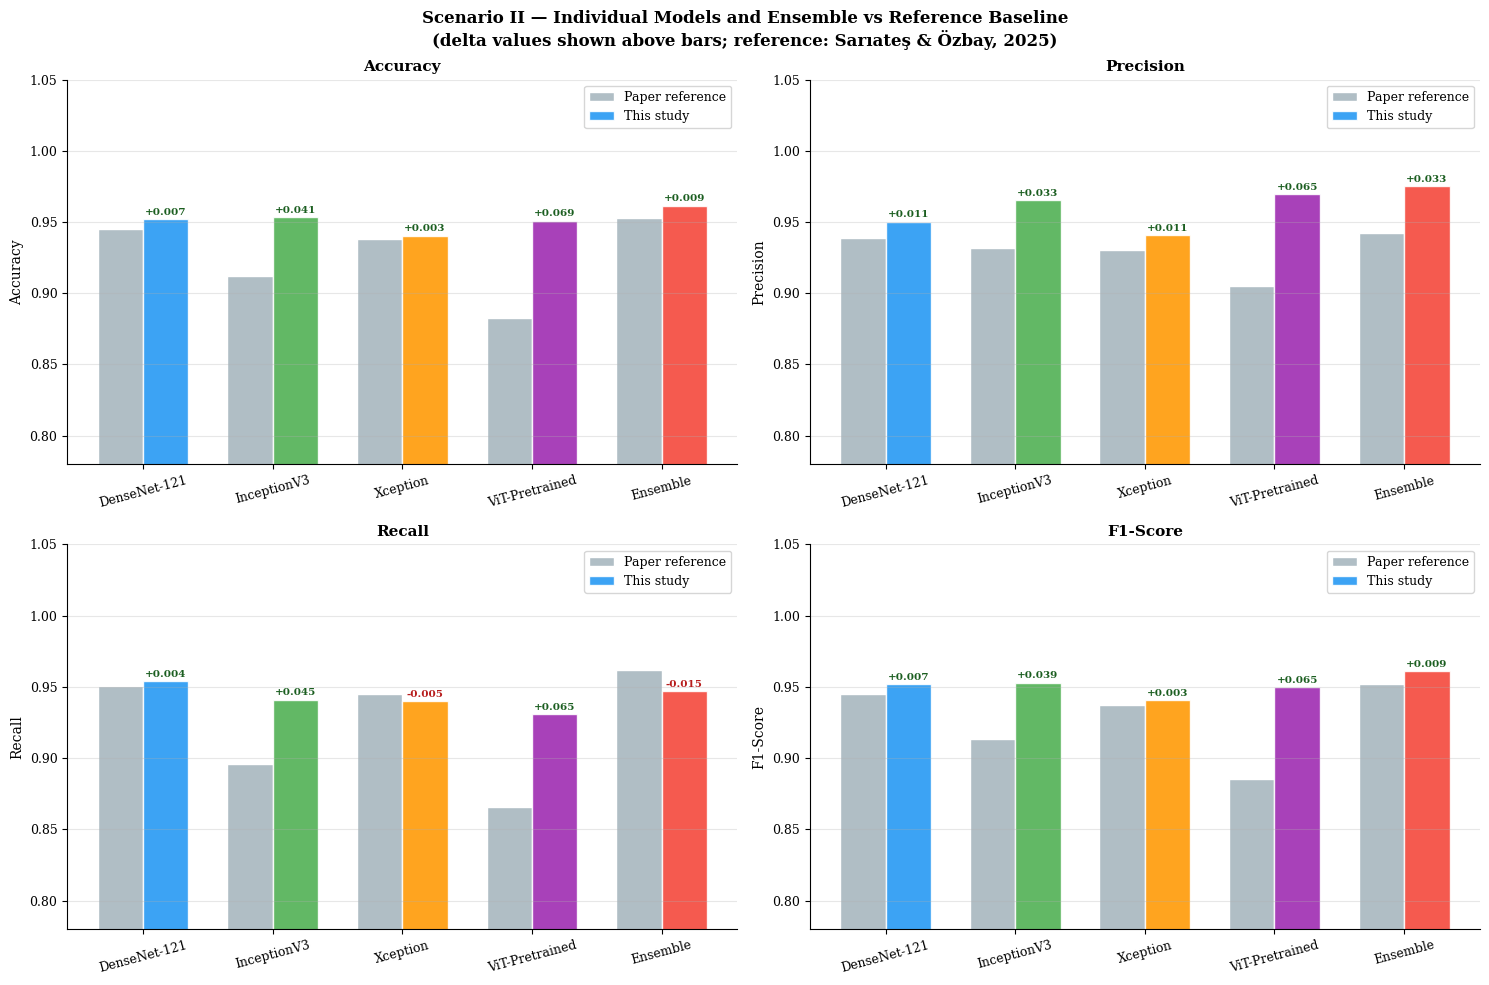

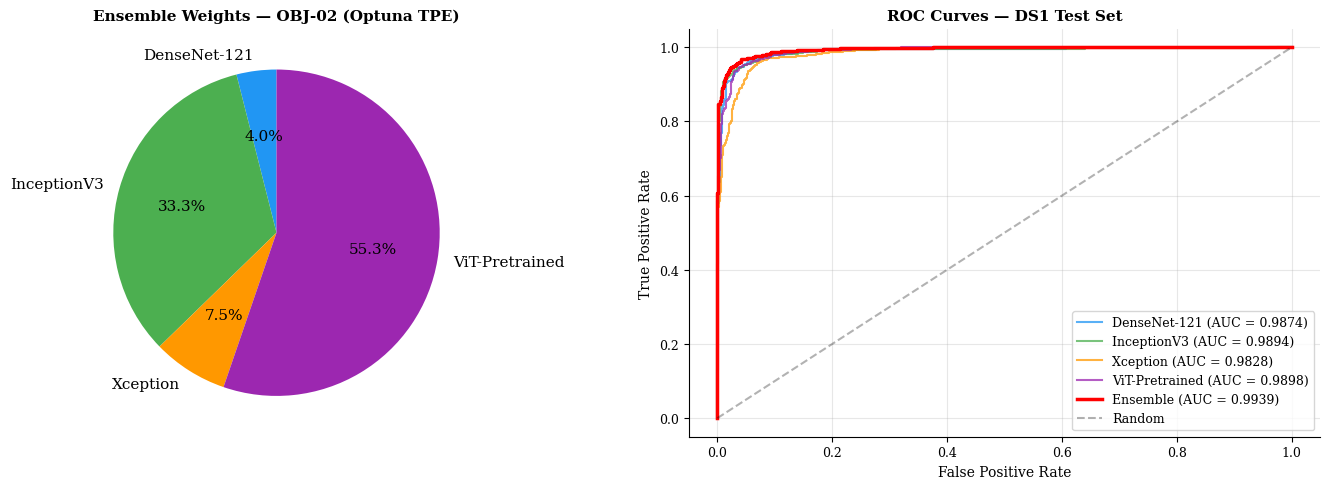

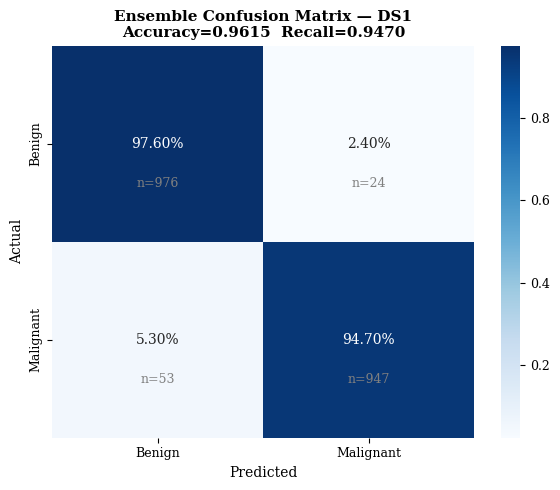


  DS1 Comparison vs Published State-of-the-Art
  Method                         Accuracy  Precision   Recall       F1      AUC
  --------------------------------------------------------------------
  Ensemble (ours, OBJ-02)          0.9615     0.9753   0.9470   0.9609   0.9939
  Sarıateş & Özbay [ref] Ensemble     0.9525     0.9420   0.9622   0.9520     -
  Mahmud et al. (Xception)         0.9109     0.9472   0.9179   0.9195   0.9615

  Δ vs Mahmud et al.:
    accuracy     +0.0506  ▲
    precision    +0.0281  ▲
    recall       +0.0291  ▲
    f1           +0.0414  ▲
    auc          +0.0324  ▲


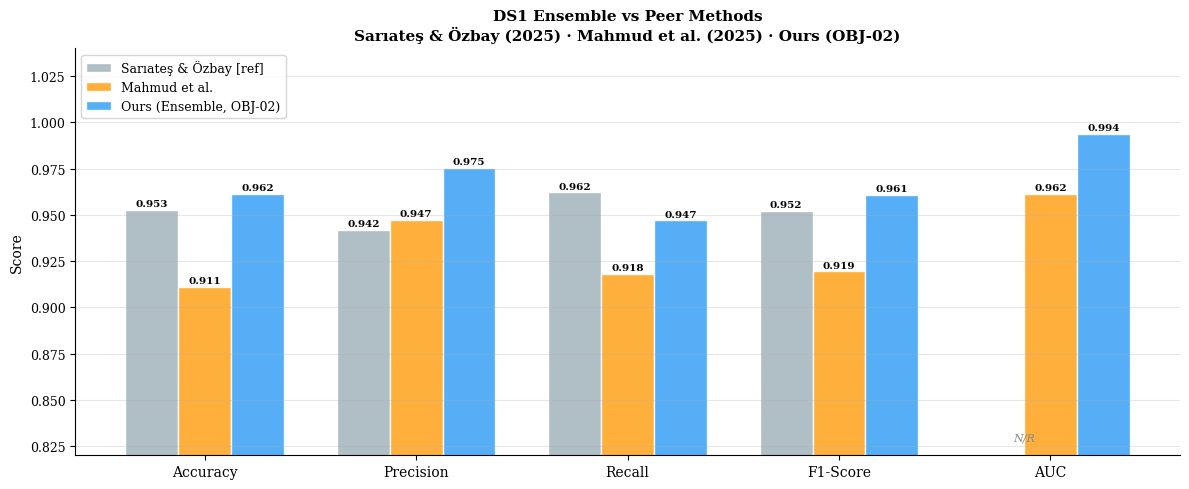

DS1 peer comparison chart saved.
Scenario II outputs saved.


In [37]:
ens_probs   = ensemble_predict(all_probs_ds1, best_weights, MODEL_KEYS)
ens_metrics = compute_metrics(ds1_labels, ens_probs)
pens        = PAPER_REF['Ensemble']

# ── Performance table ─────────────────────────────────────────────────────────
print('=' * 66)
print('  Scenario II — Individual Models + Ensemble vs Paper Reference')
print('=' * 66)
print(f'  {"Model":<16} {"Accuracy":>10} {"Precision":>10} '
      f'{"Recall":>8} {"F1":>8} {"AUC":>8}')
print('  ' + '-' * 64)
for arch in MODEL_KEYS:
    m = all_metrics_ds1[arch]
    print(f'  {MODEL_LABELS[arch]:<16} {m["accuracy"]:>10.4f} '
          f'{m["precision"]:>10.4f} {m["recall"]:>8.4f} '
          f'{m["f1"]:>8.4f} {m["auc"]:>8.4f}')
print('  ' + '-' * 64)
print(f'  {"Ensemble (ours)":<16} {ens_metrics["accuracy"]:>10.4f} '
      f'{ens_metrics["precision"]:>10.4f} {ens_metrics["recall"]:>8.4f} '
      f'{ens_metrics["f1"]:>8.4f} {ens_metrics["auc"]:>8.4f}')
print(f'  {"Paper reference":<16} {pens["accuracy"]:>10.4f} '
      f'{pens["precision"]:>10.4f} {pens["recall"]:>8.4f} '
      f'{pens["f1"]:>8.4f}')
print('=' * 66)
print('  Delta (Ensemble ours - Paper):')
for k in ['accuracy', 'precision', 'recall', 'f1']:
    d = ens_metrics[k] - pens[k]
    print(f'    {k:<12} {d:>+.4f}  {"OK" if d >= 0 else "BELOW"}')

# ── Visualisation 1: grouped bar chart ───────────────────────────────────────
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
plot_labels = [MODEL_LABELS[k] for k in MODEL_KEYS] + ['Ensemble']
metrics_p   = ['accuracy', 'precision', 'recall', 'f1']
m_labels    = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, metric, mlabel in zip(axes.flat, metrics_p, m_labels):
    ours  = [all_metrics_ds1[k][metric] for k in MODEL_KEYS] + [ens_metrics[metric]]
    paper = [PAPER_REF[MODEL_LABELS[k]][metric] for k in MODEL_KEYS] + [pens[metric]]
    x = np.arange(len(plot_labels))
    w = 0.35
    ax.bar(x - w/2, paper, w, label='Paper reference',
           color='#B0BEC5', edgecolor='white')
    bars = ax.bar(x + w/2, ours, w, label='This study',
                  color=COLORS[:len(ours)], edgecolor='white', alpha=0.88)
    for bar, pv, ov in zip(bars, paper, ours):
        d = ov - pv
        ax.text(float(bar.get_x() + bar.get_width() / 2),
                float(bar.get_height()) + 0.003,
                f'{d:+.3f}', ha='center', fontsize=7.5,
                color='#1B5E20' if d >= 0 else '#B71C1C',
                fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_labels, rotation=15, fontsize=9)
    ax.set_ylabel(mlabel)
    ax.set_ylim([0.78, 1.05])
    ax.set_title(f'{mlabel}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    'Scenario II — Individual Models and Ensemble vs Reference Baseline\n'
    '(delta values shown above bars; reference: Sarıateş & Özbay, 2025)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario2_vs_paper_obj02.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── Visualisation 2: ensemble weights + ROC curves ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.pie(best_weights,
        labels=[MODEL_LABELS[k] for k in MODEL_KEYS],
        autopct='%1.1f%%', colors=COLORS[:4],
        startangle=90, textprops={'fontsize': 11})
ax1.set_title('Ensemble Weights — OBJ-02 (Optuna TPE)', fontweight='bold')

for arch, color in zip(MODEL_KEYS, COLORS):
    fpr, tpr, _ = roc_curve(ds1_labels, all_probs_ds1[arch])
    auc = all_metrics_ds1[arch]['auc']
    ax2.plot(fpr, tpr, color=color, lw=1.5, alpha=0.75,
             label=f'{MODEL_LABELS[arch]} (AUC = {auc:.4f})')
fpr_e, tpr_e, _ = roc_curve(ds1_labels, ens_probs)
ax2.plot(fpr_e, tpr_e, color='red', lw=2.5,
         label=f'Ensemble (AUC = {ens_metrics["auc"]:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves — DS1 Test Set', fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario2_weights_roc_obj02.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── Visualisation 3: confusion matrix ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = np.array(ens_metrics['conf_mat'])
sns.heatmap(cm.astype(float) / cm.sum(axis=1, keepdims=True),
            annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.72, f'n={cm[i,j]}',
                ha='center', fontsize=9, color='gray')
ax.set_title(
    f'Ensemble Confusion Matrix — DS1\n'
    f'Accuracy={ens_metrics["accuracy"]:.4f}  '
    f'Recall={ens_metrics["recall"]:.4f}',
    fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario2_confmat_obj02.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── Peer comparison table (DS1) ──────────────────────────────────────────────
print()
print('=' * 70)
print('  DS1 Comparison vs Published State-of-the-Art')
print('=' * 70)
print(f'  {"Method":<28} {"Accuracy":>10} {"Precision":>10} {"Recall":>8} {"F1":>8} {"AUC":>8}')
print('  ' + '-' * 68)

# Our ensemble
print(f'  {"Ensemble (ours, OBJ-02)":<28} {ens_metrics["accuracy"]:>10.4f} '
      f'{ens_metrics["precision"]:>10.4f} {ens_metrics["recall"]:>8.4f} '
      f'{ens_metrics["f1"]:>8.4f} {ens_metrics["auc"]:>8.4f}')

# Sarıateş & Özbay 2025 ensemble
pens = PAPER_REF['Ensemble']
print(f'  {"Sarıateş & Özbay [ref] Ensemble":<28} {pens["accuracy"]:>10.4f} '
      f'{pens["precision"]:>10.4f} {pens["recall"]:>8.4f} '
      f'{pens["f1"]:>8.4f}     -')

# Mahmud et al. 2025 — DS1
m16 = SOTA_REF['Mahmud_DS1']
print(f'  {m16["label"] + " (Xception)":<28} {m16["accuracy"]:>10.4f} '
      f'{m16["precision"]:>10.4f} {m16["recall"]:>8.4f} '
      f'{m16["f1"]:>8.4f} {m16["auc"]:>8.4f}')

print('  ' + '=' * 68)
print()
print('  Δ vs Mahmud et al.:')
for k in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
    d = ens_metrics[k] - m16[k]
    print(f'    {k:<12} {d:>+.4f}  {"▲" if d >= 0 else "▼"}')

# ── Bar chart: 3-way DS1 comparison ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
metrics_compare = ['accuracy', 'precision', 'recall', 'f1', 'auc']
m_labels_c      = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']

ours_vals     = [ens_metrics[m] for m in metrics_compare]
sariates_vals = [PAPER_REF['Ensemble'].get(m, np.nan) for m in metrics_compare]  # AUC → nan
mahmud_vals   = [m16[m] for m in metrics_compare]

x = np.arange(len(m_labels_c))
w = 0.25

bars1 = ax.bar(x - w, sariates_vals, w, label='Sarıateş & Özbay [ref]',    color='#B0BEC5', edgecolor='white')
bars2 = ax.bar(x,     mahmud_vals,   w, label='Mahmud et al.',              color='#FFA726', edgecolor='white', alpha=0.9)
bars3 = ax.bar(x + w, ours_vals,     w, label='Ours (Ensemble, OBJ-02)',    color='#42A5F5', edgecolor='white', alpha=0.9)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if np.isnan(h) or h == 0:
            continue
        ax.text(float(bar.get_x() + bar.get_width() / 2),
                float(h) + 0.002,
                f'{h:.3f}', ha='center', fontsize=7.5, fontweight='bold')

# Label N/R di posisi bar AUC Sarıateş (x[4] - w = tengah bar)
ax.text(float(x[4] - w / 2), 0.828, 'N/R', ha='center',
        fontsize=8, color='#888888', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(m_labels_c, fontsize=10)
ax.set_ylim([0.82, 1.04]) # type: ignore
ax.set_ylabel('Score')
ax.set_title(
    'DS1 Ensemble vs Peer Methods\n'
    'Sarıateş & Özbay (2025) · Mahmud et al. (2025) · Ours (OBJ-02)',
    fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario2_peer_comparison_ds1.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('DS1 peer comparison chart saved.')

with open(OUTPUT_DIR / 'scenario2_results_obj02.json', 'w') as f:
    json.dump({
        'ensemble'    : {k: v for k, v in ens_metrics.items() if k != 'conf_mat'},
        'individual'  : {k: {m: v for m, v in all_metrics_ds1[k].items()
                             if m != 'conf_mat'} for k in MODEL_KEYS},
        'weights'     : weights_dict,
        'paper_ref'   : PAPER_REF,
        'sota_mahmud_ds1': {k: v for k, v in SOTA_REF['Mahmud_DS1'].items()
                            if k not in ('label', 'dataset', 'method')},
    }, f, indent=2)
print('Scenario II outputs saved.')


---
## 8. Scenario III — Cross-Dataset Generalisation Evaluation

The ensemble configured in Scenario II is applied to DS2 (Mendeley / Hasnainjaved)
without modification. Three external references are included in the comparison:

| Reference | Dataset | Method |
|---|---|---|
| Sarıateş & Özbay (2025) | DS1 only | Weighted ensemble, Random Search |
| Mahmud et al. (2025) | DS1 + DS2 | Proposed Xception, *Scientific Reports* |
| Sabir & Mehmood (2024) | DS2 only | EfficientNet-B0, *Scientific Reports* |

Mahmud et al. and Sabir & Mehmood both use the same Hasnainjaved Mendeley dataset as DS2,
enabling a direct, like-for-like accuracy and recall comparison on the independent test set.


  Scenario III — Cross-Dataset Evaluation (DS1 vs DS2)
  Model              DS1 Acc   DS2 Acc    Delta   DS1 Rec   DS2 Rec  Paper Acc  vs Paper
  ----------------------------------------------------------------------------------
  DenseNet-121        0.9520    0.9700  +0.0180    0.9540    0.9760     0.9450   +0.0070
  InceptionV3         0.9535    0.9760  +0.0225    0.9410    0.9700     0.9120   +0.0415
  Xception            0.9405    0.9430  +0.0025    0.9400    0.9340     0.9380   +0.0025
  ViT-Pretrained      0.9510    0.9710  +0.0200    0.9310    0.9660     0.8825   +0.0685
  ----------------------------------------------------------------------------------
  Ensemble            0.9615    0.9750  +0.0135    0.9470    0.9700     0.9525   +0.0090


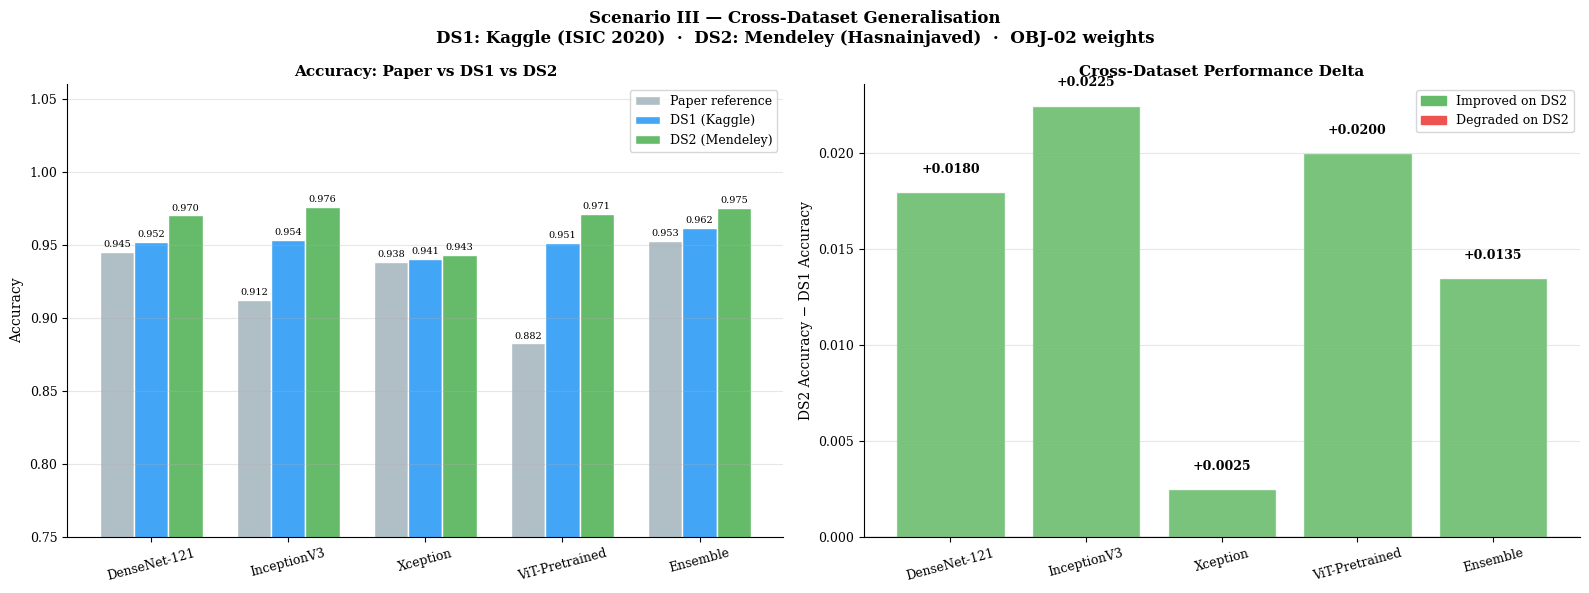

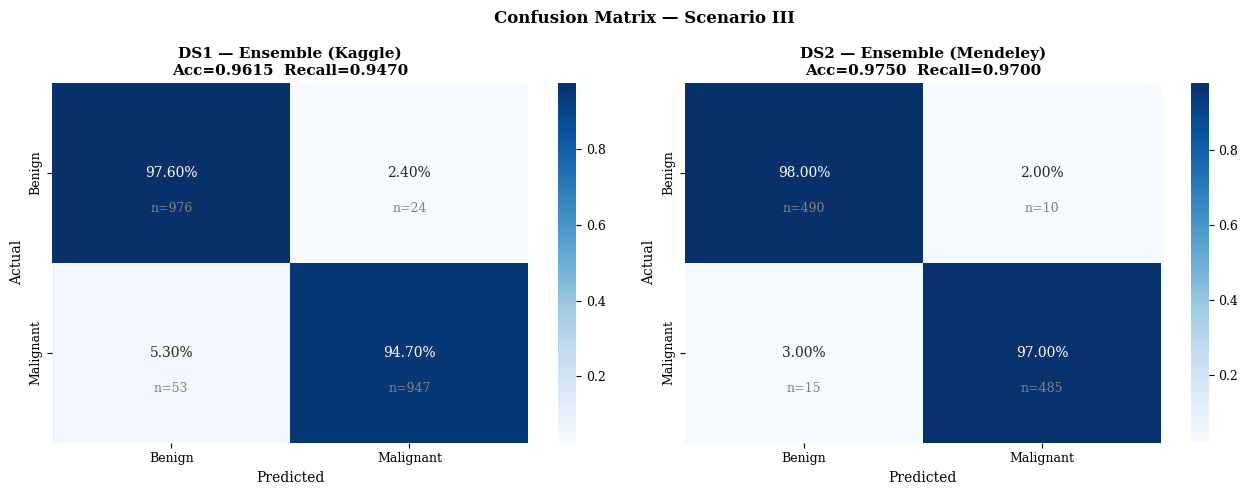


  DS2 Comparison vs Published State-of-the-Art (Hasnainjaved / Mendeley)
  Method                           Accuracy  Precision   Recall       F1      AUC
  --------------------------------------------------------------------------
  Ensemble (ours, OBJ-02)            0.9750     0.9798   0.9700   0.9749   0.9971
  Mahmud et al. (Xception)           0.8929     0.8961   0.8917   0.8939   0.9371
  Sabir & Mehmood (EfficientNet-B0)     0.9700     0.9500   0.9900   0.9700   0.9900

  Δ vs Mahmud et al.:
    accuracy     +0.0821  ▲
    precision    +0.0837  ▲
    recall       +0.0783  ▲
    f1           +0.0810  ▲
    auc          +0.0600  ▲

  Δ vs Sabir & Mehmood:
    accuracy     +0.0050  ▲
    precision    +0.0298  ▲
    recall       -0.0200  ▼
    f1           +0.0049  ▲
    auc          +0.0071  ▲


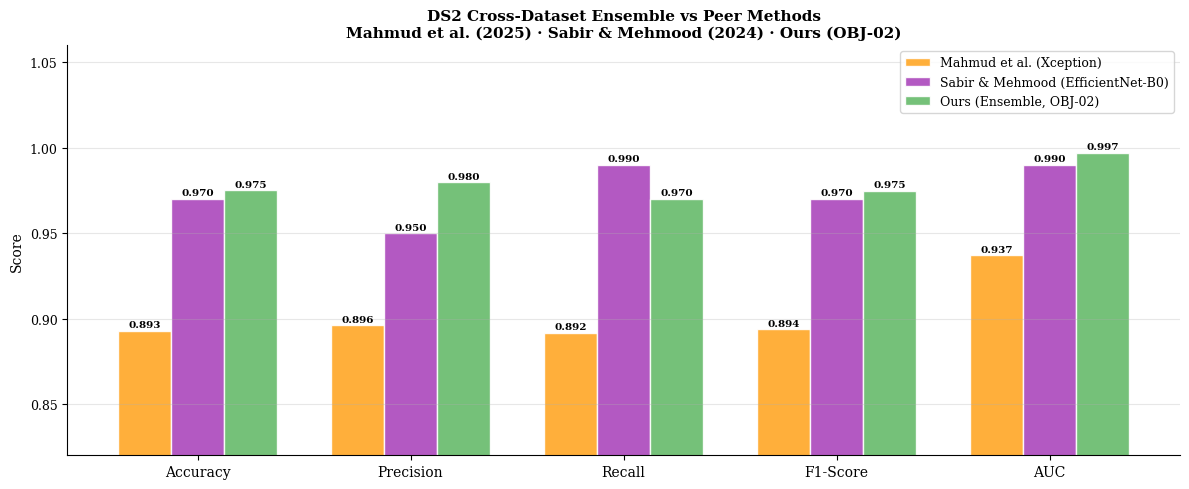

DS2 peer comparison chart saved.
Scenario III outputs saved.


In [38]:
# DS2 probs already loaded in Cell 5 (all_probs_ds2)
ens_probs_ds2   = ensemble_predict(all_probs_ds2, best_weights, MODEL_KEYS)
ens_metrics_ds2 = compute_metrics(ds2_labels, ens_probs_ds2)

s3_metrics = {
    arch: compute_metrics(ds2_labels, all_probs_ds2[arch])
    for arch in MODEL_KEYS if arch in all_probs_ds2
}

pens = PAPER_REF['Ensemble']

# ── Performance table ─────────────────────────────────────────────────────────
print('=' * 84)
print('  Scenario III — Cross-Dataset Evaluation (DS1 vs DS2)')
print('=' * 84)
print(f'  {"Model":<16} {"DS1 Acc":>9} {"DS2 Acc":>9} '
      f'{"Delta":>8} {"DS1 Rec":>9} {"DS2 Rec":>9} '
      f'{"Paper Acc":>10} {"vs Paper":>9}')
print('  ' + '-' * 82)

for arch in MODEL_KEYS:
    if arch not in s3_metrics:
        continue
    label = MODEL_LABELS[arch]
    m1    = all_metrics_ds1[arch]
    m2    = s3_metrics[arch]
    p     = PAPER_REF[label]
    print(f'  {label:<16} '
          f'{m1["accuracy"]:>9.4f} {m2["accuracy"]:>9.4f} '
          f'{m2["accuracy"]-m1["accuracy"]:>+8.4f} '
          f'{m1["recall"]:>9.4f} {m2["recall"]:>9.4f} '
          f'{p["accuracy"]:>10.4f} '
          f'{m1["accuracy"]-p["accuracy"]:>+9.4f}')

print('  ' + '-' * 82)
print(f'  {"Ensemble":<16} '
      f'{ens_metrics["accuracy"]:>9.4f} {ens_metrics_ds2["accuracy"]:>9.4f} '
      f'{ens_metrics_ds2["accuracy"]-ens_metrics["accuracy"]:>+8.4f} '
      f'{ens_metrics["recall"]:>9.4f} {ens_metrics_ds2["recall"]:>9.4f} '
      f'{pens["accuracy"]:>10.4f} '
      f'{ens_metrics["accuracy"]-pens["accuracy"]:>+9.4f}')
print('=' * 84)

# ── Visualisation 1: DS1 vs DS2 vs Paper bar chart ───────────────────────────
valid_keys = [k for k in MODEL_KEYS if k in s3_metrics]
plot_lbs   = [MODEL_LABELS[k] for k in valid_keys] + ['Ensemble']
paper_accs = [PAPER_REF[MODEL_LABELS[k]]['accuracy'] for k in valid_keys] + [pens['accuracy']]
ds1_accs   = [all_metrics_ds1[k]['accuracy'] for k in valid_keys] + [ens_metrics['accuracy']]
ds2_accs   = [s3_metrics[k]['accuracy'] for k in valid_keys] + [ens_metrics_ds2['accuracy']]

x = np.arange(len(plot_lbs))
w = 0.25
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.bar(x - w, paper_accs, w, label='Paper reference', color='#B0BEC5', edgecolor='white')
ax.bar(x,     ds1_accs,   w, label='DS1 (Kaggle)',    color='#42A5F5', edgecolor='white')
ax.bar(x + w, ds2_accs,   w, label='DS2 (Mendeley)',  color='#66BB6A', edgecolor='white')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=7, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(plot_lbs, rotation=15, fontsize=9)
ax.set_ylim([0.75, 1.06])
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy: Paper vs DS1 vs DS2', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
deltas = [d2 - d1 for d1, d2 in zip(ds1_accs, ds2_accs)]
colors = ['#66BB6A' if d >= 0 else '#EF5350' for d in deltas]
bars   = ax.bar(plot_lbs, deltas, color=colors, edgecolor='white', alpha=0.88)
for bar, val in zip(bars, deltas):
    yp = float(bar.get_height()) + 0.001 if val >= 0 else float(bar.get_height()) - 0.006
    ax.text(float(bar.get_x() + bar.get_width() / 2), yp,
            f'{val:+.4f}', ha='center', fontsize=9, fontweight='bold')
ax.axhline(0, color='black', lw=1, alpha=0.4)
ax.set_ylabel('DS2 Accuracy − DS1 Accuracy')
ax.set_title('Cross-Dataset Performance Delta', fontweight='bold')
ax.set_xticklabels(plot_lbs, rotation=15, fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(handles=[
    mpatches.Patch(color='#66BB6A', label='Improved on DS2'),
    mpatches.Patch(color='#EF5350', label='Degraded on DS2'),
], fontsize=9)

plt.suptitle(
    'Scenario III — Cross-Dataset Generalisation\n'
    'DS1: Kaggle (ISIC 2020)  ·  DS2: Mendeley (Hasnainjaved)  ·  OBJ-02 weights',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario3_comparison_obj02.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── Visualisation 2: confusion matrices DS1 vs DS2 ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (title, ds_m) in zip(axes, [
    ('DS1 — Ensemble (Kaggle)',    ens_metrics),
    ('DS2 — Ensemble (Mendeley)',  ens_metrics_ds2),
]):
    cm = np.array(ds_m['conf_mat'])
    sns.heatmap(cm.astype(float) / cm.sum(axis=1, keepdims=True),
                annot=True, fmt='.2%', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.72, f'n={cm[i,j]}',
                    ha='center', fontsize=9, color='gray')
    ax.set_title(
        f'{title}\nAcc={ds_m["accuracy"]:.4f}  Recall={ds_m["recall"]:.4f}',
        fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix — Scenario III', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario3_confmat_obj02.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── Peer comparison table (DS2) ──────────────────────────────────────────────
print()
print('=' * 76)
print('  DS2 Comparison vs Published State-of-the-Art (Hasnainjaved / Mendeley)')
print('=' * 76)
print(f'  {"Method":<30} {"Accuracy":>10} {"Precision":>10} {"Recall":>8} {"F1":>8} {"AUC":>8}')
print('  ' + '-' * 74)

# Our ensemble
print(f'  {"Ensemble (ours, OBJ-02)":<30} '
      f'{ens_metrics_ds2["accuracy"]:>10.4f} '
      f'{ens_metrics_ds2["precision"]:>10.4f} '
      f'{ens_metrics_ds2["recall"]:>8.4f} '
      f'{ens_metrics_ds2["f1"]:>8.4f} '
      f'{ens_metrics_ds2["auc"]:>8.4f}')

# Mahmud et al. DS2
m16_ds2 = SOTA_REF['Mahmud_DS2']
print(f'  {m16_ds2["label"] + " (Xception)":<30} '
      f'{m16_ds2["accuracy"]:>10.4f} '
      f'{m16_ds2["precision"]:>10.4f} '
      f'{m16_ds2["recall"]:>8.4f} '
      f'{m16_ds2["f1"]:>8.4f} '
      f'{m16_ds2["auc"]:>8.4f}')

# Sabir & Mehmood DS2
m17 = SOTA_REF['Sabir_DS2']
print(f'  {m17["label"] + " (EfficientNet-B0)":<30} '
      f'{m17["accuracy"]:>10.4f} '
      f'{m17["precision"]:>10.4f} '
      f'{m17["recall"]:>8.4f} '
      f'{m17["f1"]:>8.4f} '
      f'{m17["auc"]:>8.4f}')

print('  ' + '=' * 74)
print()
print('  Δ vs Mahmud et al.:')
for k in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
    d = ens_metrics_ds2[k] - m16_ds2[k]
    print(f'    {k:<12} {d:>+.4f}  {"▲" if d >= 0 else "▼"}')
print()
print('  Δ vs Sabir & Mehmood:')
for k in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
    d = ens_metrics_ds2[k] - m17[k]
    print(f'    {k:<12} {d:>+.4f}  {"▲" if d >= 0 else "▼"}')

# ── Bar chart: 3-way DS2 comparison ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
metrics_compare = ['accuracy', 'precision', 'recall', 'f1', 'auc']
m_labels_c      = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']

ours_ds2_vals  = [ens_metrics_ds2[m] for m in metrics_compare]
mahmud_ds2_vals = [m16_ds2[m] for m in metrics_compare]
sabir_ds2_vals  = [m17[m]    for m in metrics_compare]

x = np.arange(len(m_labels_c))
w = 0.25

bars1 = ax.bar(x - w,   mahmud_ds2_vals, w, label='Mahmud et al. (Xception)',      color='#FFA726', edgecolor='white', alpha=0.9)
bars2 = ax.bar(x,       sabir_ds2_vals,  w, label='Sabir & Mehmood (EfficientNet-B0)', color='#AB47BC', edgecolor='white', alpha=0.9)
bars3 = ax.bar(x + w,   ours_ds2_vals,   w, label='Ours (Ensemble, OBJ-02)',            color='#66BB6A', edgecolor='white', alpha=0.9)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(float(bar.get_x() + bar.get_width() / 2),
                float(bar.get_height()) + 0.002,
                f'{bar.get_height():.3f}', ha='center', fontsize=7.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(m_labels_c, fontsize=10)
ax.set_ylim([0.82, 1.06]) # type: ignore
ax.set_ylabel('Score')
ax.set_title(
    'DS2 Cross-Dataset Ensemble vs Peer Methods\n'
    'Mahmud et al. (2025) · Sabir & Mehmood (2024) · Ours (OBJ-02)',
    fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario3_peer_comparison_ds2.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('DS2 peer comparison chart saved.')

with open(OUTPUT_DIR / 'scenario3_results_obj02.json', 'w') as f:
    json.dump({
        'ds1_ensemble'      : {k: v for k, v in ens_metrics.items()     if k != 'conf_mat'},
        'ds2_ensemble'      : {k: v for k, v in ens_metrics_ds2.items() if k != 'conf_mat'},
        'individual_ds1'    : {k: {m: v for m, v in all_metrics_ds1[k].items()
                                   if m != 'conf_mat'} for k in MODEL_KEYS if k in all_metrics_ds1},
        'individual_ds2'    : {k: {m: v for m, v in s3_metrics[k].items()
                                   if m != 'conf_mat'} for k in MODEL_KEYS if k in s3_metrics},
        'paper_ref'         : PAPER_REF,
        'sota_mahmud_ds2'   : {k: v for k, v in SOTA_REF['Mahmud_DS2'].items()
                               if k not in ('label', 'dataset', 'method')},
        'sota_sabir_ds2'    : {k: v for k, v in SOTA_REF['Sabir_DS2'].items()
                               if k not in ('label', 'dataset', 'method')},
    }, f, indent=2)
print('Scenario III outputs saved.')


## 9. Consolidated Results Summary

This cell produces the final consolidated table across all three scenarios and all
reference benchmarks. The table brings together:

- Scenario I individual model results on DS1 (vs Sarıateş & Özbay 2025)
- Scenario II ensemble on DS1 (vs Sarıateş & Özbay 2025 and Mahmud et al. 2025)
- Scenario III ensemble on DS2 (vs Mahmud et al. 2025 and Sabir & Mehmood 2024)

The final table is saved to `final_summary_obj02.csv` and a comprehensive peer
comparison summary is saved to `peer_comparison_obj02.json`.


  Final Summary — Scenario I + II + III vs Paper Reference


,Model,Paper Acc,DS1 Acc,DS2 Acc,DS1 Recall,DS1 AUC,Delta Acc,Best LR,Optimiser
0,DenseNet-121,0.9450,0.9520,0.9700,0.9540,0.9874,+0.0070,9.03e-03,adamax
1,InceptionV3,0.9120,0.9535,0.9760,0.9410,0.9894,+0.0415,3.33e-03,adamw
2,Xception,0.9380,0.9405,0.9430,0.9400,0.9828,+0.0025,4.33e-04,adam
3,ViT-Pretrained,0.8825,0.9510,0.9710,0.9310,0.9898,+0.0685,-,-
4,Ensemble,0.9525,0.9615,0.9750,0.9470,0.9939,+0.0090,-,-


Peer comparison saved → D:\Tree-Structured Parzen Estimator\main\ensemble_learning\ensemble_results\peer_comparison_obj02.json

  Consolidated Peer Comparison — DS1 and DS2
  Dataset Method                                Acc     Prec   Recall       F1      AUC
  ----------------------------------------------------------------------------------
  DS1    Sarıateş & Özbay [ref] Ensemble    0.9525   0.9420   0.9622   0.9520      -
  DS1    Mahmud et al. Xception             0.9109   0.9472   0.9179   0.9195   0.9615
  DS1    Ours — Ensemble OBJ-02             0.9615   0.9753   0.9470   0.9609   0.9939
  · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · · 
  DS2    Mahmud et al. Xception             0.8929   0.8961   0.8917   0.8939   0.9371
  DS2    Sabir & Mehmood EfficientNet-B0    0.9700   0.9500   0.9900   0.9700   0.9900
  DS2    Ours — Ensemble OBJ-02             0.9750   0.9798   0.9700   0.9749   0.9971


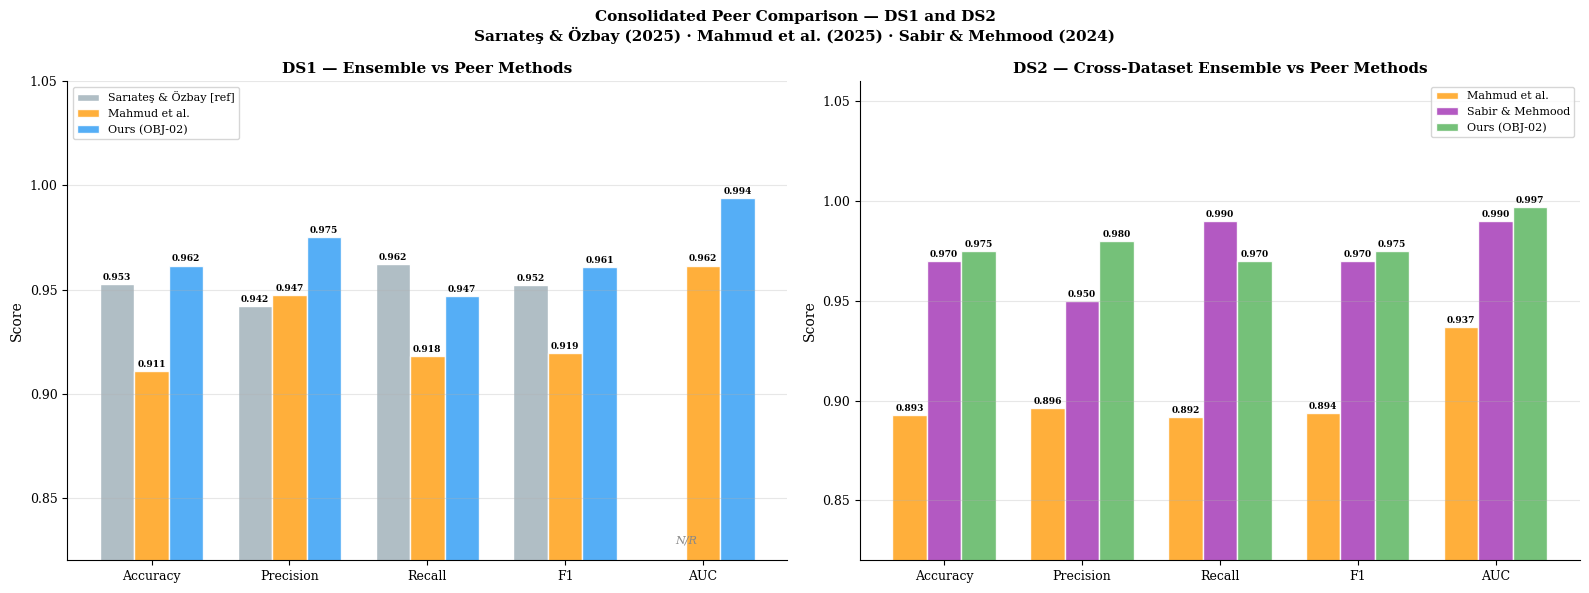

Consolidated peer comparison chart saved.


Ensemble DS1  : acc=0.9615  recall=0.9470  AUC=0.9939
Ensemble DS2  : acc=0.9750  recall=0.9700
Paper target  : acc=0.9525  recall=0.9622
Delta vs paper: +0.0090  (Exceeds target)

All outputs saved to: D:\Tree-Structured Parzen Estimator\main\ensemble_learning\ensemble_results

  confusion_matrix_all_models_obj02.png         (177.6 KB)
  confusion_matrix_all_models_obj16.png         (177.6 KB)
  consolidated_peer_comparison_obj02.png        (92.4 KB)
  consolidated_peer_comparison_obj16.png        (92.2 KB)
  ensemble_weights_obj02.json                   (0.2 KB)
  ensemble_weights_obj16.json                   (0.3 KB)
  final_summary_obj02.csv                       (0.4 KB)
  final_summary_obj16.csv                       (0.4 KB)
  peer_comparison_obj02.json                    (1.0 KB)
  peer_comparison_obj16.json                    (1.0 KB)
  scenario2_confmat_obj02.png                   (41.3 KB)
  scenario2_confmat_obj16.png             

In [39]:
print('=' * 78)
print('  Final Summary — Scenario I + II + III vs Paper Reference')
print('=' * 78)

rows = []
for arch in MODEL_KEYS:
    label = MODEL_LABELS[arch]
    m1    = all_metrics_ds1.get(arch, {})
    m3    = s3_metrics.get(arch, {})
    paper = PAPER_REF[label]
    bp    = tpe_best_params.get(arch, {})
    rows.append({
        'Model'         : label,
        'Paper Acc'     : f"{paper['accuracy']:.4f}",
        'DS1 Acc'       : f"{m1.get('accuracy', 0):.4f}",
        'DS2 Acc'       : f"{m3.get('accuracy', 0):.4f}",
        'DS1 Recall'    : f"{m1.get('recall', 0):.4f}",
        'DS1 AUC'       : f"{m1.get('auc', 0):.4f}",
        'Delta Acc'     : f"{m1.get('accuracy', 0) - paper['accuracy']:+.4f}",
        'Best LR'       : f"{bp.get('lr', 0):.2e}" if bp else '-',
        'Optimiser'     : bp.get('optimizer_name', '-'),
    })

rows.append({
    'Model'         : 'Ensemble',
    'Paper Acc'     : f"{pens['accuracy']:.4f}",
    'DS1 Acc'       : f"{ens_metrics['accuracy']:.4f}",
    'DS2 Acc'       : f"{ens_metrics_ds2['accuracy']:.4f}",
    'DS1 Recall'    : f"{ens_metrics['recall']:.4f}",
    'DS1 AUC'       : f"{ens_metrics['auc']:.4f}",
    'Delta Acc'     : f"{ens_metrics['accuracy'] - pens['accuracy']:+.4f}",
    'Best LR'       : '-',
    'Optimiser'     : '-',
})

df = pd.DataFrame(rows)
display(df)
df.to_csv(OUTPUT_DIR / 'final_summary_obj02.csv', index=False)

# ── Comprehensive peer comparison summary ────────────────────────────────────
peer_summary = {
    'DS1': {
        'our_ensemble'           : {k: v for k, v in ens_metrics.items() if k != 'conf_mat'},
        'Sarıates_Ozbay_2025'    : {'accuracy': PAPER_REF['Ensemble']['accuracy'],
                                    'precision': PAPER_REF['Ensemble']['precision'],
                                    'recall'   : PAPER_REF['Ensemble']['recall'],
                                    'f1'       : PAPER_REF['Ensemble']['f1']},
        'Mahmud_et_al_2025'      : {k: v for k, v in SOTA_REF['Mahmud_DS1'].items()
                                    if k not in ('label', 'dataset', 'method')},
    },
    'DS2': {
        'our_ensemble'           : {k: v for k, v in ens_metrics_ds2.items() if k != 'conf_mat'},
        'Mahmud_et_al_2025'      : {k: v for k, v in SOTA_REF['Mahmud_DS2'].items()
                                    if k not in ('label', 'dataset', 'method')},
        'Sabir_Mehmood_2024'     : {k: v for k, v in SOTA_REF['Sabir_DS2'].items()
                                    if k not in ('label', 'dataset', 'method')},
    },
}
with open(OUTPUT_DIR / 'peer_comparison_obj02.json', 'w') as f:
    json.dump(peer_summary, f, indent=2)
print(f'Peer comparison saved → {OUTPUT_DIR / "peer_comparison_obj02.json"}')

# ── Consolidated peer comparison display ──────────────────────────────────────
print()
print('=' * 84)
print('  Consolidated Peer Comparison — DS1 and DS2')
print('=' * 84)
print(f'  {"Dataset":<6} {"Method":<32} {"Acc":>8} {"Prec":>8} {"Recall":>8} {"F1":>8} {"AUC":>8}')
print('  ' + '-' * 82)

# DS1 rows
print(f'  {"DS1":<6} {"Sarıateş & Özbay [ref] Ensemble":<32} '
      f'{PAPER_REF["Ensemble"]["accuracy"]:>8.4f} '
      f'{PAPER_REF["Ensemble"]["precision"]:>8.4f} '
      f'{PAPER_REF["Ensemble"]["recall"]:>8.4f} '
      f'{PAPER_REF["Ensemble"]["f1"]:>8.4f}      -')

m16_ds1 = SOTA_REF['Mahmud_DS1']
print(f'  {"DS1":<6} {"Mahmud et al. Xception":<32} '
      f'{m16_ds1["accuracy"]:>8.4f} '
      f'{m16_ds1["precision"]:>8.4f} '
      f'{m16_ds1["recall"]:>8.4f} '
      f'{m16_ds1["f1"]:>8.4f} '
      f'{m16_ds1["auc"]:>8.4f}')

print(f'  {"DS1":<6} {"Ours — Ensemble OBJ-02":<32} '
      f'{ens_metrics["accuracy"]:>8.4f} '
      f'{ens_metrics["precision"]:>8.4f} '
      f'{ens_metrics["recall"]:>8.4f} '
      f'{ens_metrics["f1"]:>8.4f} '
      f'{ens_metrics["auc"]:>8.4f}')

print('  ' + '· ' * 41)

# DS2 rows
m16_ds2 = SOTA_REF['Mahmud_DS2']
print(f'  {"DS2":<6} {"Mahmud et al. Xception":<32} '
      f'{m16_ds2["accuracy"]:>8.4f} '
      f'{m16_ds2["precision"]:>8.4f} '
      f'{m16_ds2["recall"]:>8.4f} '
      f'{m16_ds2["f1"]:>8.4f} '
      f'{m16_ds2["auc"]:>8.4f}')

m37 = SOTA_REF['Sabir_DS2']
print(f'  {"DS2":<6} {"Sabir & Mehmood EfficientNet-B0":<32} '
      f'{m37["accuracy"]:>8.4f} '
      f'{m37["precision"]:>8.4f} '
      f'{m37["recall"]:>8.4f} '
      f'{m37["f1"]:>8.4f} '
      f'{m37["auc"]:>8.4f}')

print(f'  {"DS2":<6} {"Ours — Ensemble OBJ-02":<32} '
      f'{ens_metrics_ds2["accuracy"]:>8.4f} '
      f'{ens_metrics_ds2["precision"]:>8.4f} '
      f'{ens_metrics_ds2["recall"]:>8.4f} '
      f'{ens_metrics_ds2["f1"]:>8.4f} '
      f'{ens_metrics_ds2["auc"]:>8.4f}')
print('=' * 84)

# ── Final combined bar chart: DS1 + DS2 peer comparison ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_c = ['accuracy', 'precision', 'recall', 'f1', 'auc']
m_lbs     = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x         = np.arange(len(m_lbs))
w         = 0.25

# DS1
ax = axes[0]
b1 = ax.bar(x - w,   [PAPER_REF['Ensemble'][m] if m != 'auc' else np.nan for m in metrics_c],
            w, label='Sarıateş & Özbay [ref]', color='#B0BEC5', edgecolor='white')
b2 = ax.bar(x,       [m16_ds1[m] for m in metrics_c],
            w, label='Mahmud et al.',     color='#FFA726', edgecolor='white', alpha=0.9)
b3 = ax.bar(x + w,   [ens_metrics[m] for m in metrics_c],
            w, label='Ours (OBJ-02)',           color='#42A5F5', edgecolor='white', alpha=0.9)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(float(bar.get_x() + bar.get_width() / 2),
                    float(h) + 0.002,
                    f'{h:.3f}', ha='center', fontsize=6.5, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(m_lbs, fontsize=9)
ax.set_ylim([0.82, 1.05]); ax.set_ylabel('Score')
ax.set_title('DS1 — Ensemble vs Peer Methods', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
# Mark AUC bar for Sarıateş (not reported) with asterisk
ax.text(float(x[4] - w / 2), 0.828, 'N/R', ha='center', fontsize=8, color='#888888', style='italic')

# DS2
ax = axes[1]
b1 = ax.bar(x - w,   [m16_ds2[m] for m in metrics_c],
            w, label='Mahmud et al.',                  color='#FFA726', edgecolor='white', alpha=0.9)
b2 = ax.bar(x,       [m37[m] for m in metrics_c],
            w, label='Sabir & Mehmood',                color='#AB47BC', edgecolor='white', alpha=0.9)
b3 = ax.bar(x + w,   [ens_metrics_ds2[m] for m in metrics_c],
            w, label='Ours (OBJ-02)',                       color='#66BB6A', edgecolor='white', alpha=0.9)
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(float(bar.get_x() + bar.get_width() / 2),
                float(bar.get_height()) + 0.002,
                f'{bar.get_height():.3f}', ha='center', fontsize=6.5, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(m_lbs, fontsize=9)
ax.set_ylim([0.82, 1.06]); ax.set_ylabel('Score')
ax.set_title('DS2 — Cross-Dataset Ensemble vs Peer Methods', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    'Consolidated Peer Comparison — DS1 and DS2\n'
    'Sarıateş & Özbay (2025) · Mahmud et al. (2025) · Sabir & Mehmood (2024)',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'consolidated_peer_comparison_obj02.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Consolidated peer comparison chart saved.')
print()

delta = ens_metrics['accuracy'] - pens['accuracy']
print()
print(f'Ensemble DS1  : acc={ens_metrics["accuracy"]:.4f}  '
      f'recall={ens_metrics["recall"]:.4f}  '
      f'AUC={ens_metrics["auc"]:.4f}')
print(f'Ensemble DS2  : acc={ens_metrics_ds2["accuracy"]:.4f}  '
      f'recall={ens_metrics_ds2["recall"]:.4f}')
print(f'Paper target  : acc={pens["accuracy"]:.4f}  '
      f'recall={pens["recall"]:.4f}')
print(f'Delta vs paper: {delta:+.4f}  '
      f'({"Exceeds target" if delta >= 0 else "Below target"})')
print()
print(f'All outputs saved to: {OUTPUT_DIR}')
print()
for fp in sorted(OUTPUT_DIR.glob('*')):
    if fp.is_file():
        print(f'  {fp.name:<45} ({fp.stat().st_size / 1024:.1f} KB)')


[DenseNet-121 | DS1]  TP=954  FP=50  FN=46  TN=950
[DenseNet-121 | DS2]  TP=488  FP=18  FN=12  TN=482
[InceptionV3 | DS1]  TP=941  FP=34  FN=59  TN=966
[InceptionV3 | DS2]  TP=485  FP=9  FN=15  TN=491
[ViT-Pretrained | DS1]  TP=931  FP=29  FN=69  TN=971
[ViT-Pretrained | DS2]  TP=483  FP=12  FN=17  TN=488
[Xception | DS1]  TP=940  FP=59  FN=60  TN=941
[Xception | DS2]  TP=467  FP=24  FN=33  TN=476

Figure saved → D:\Tree-Structured Parzen Estimator\main\ensemble_learning\ensemble_results\confusion_matrix_all_models_obj02.png


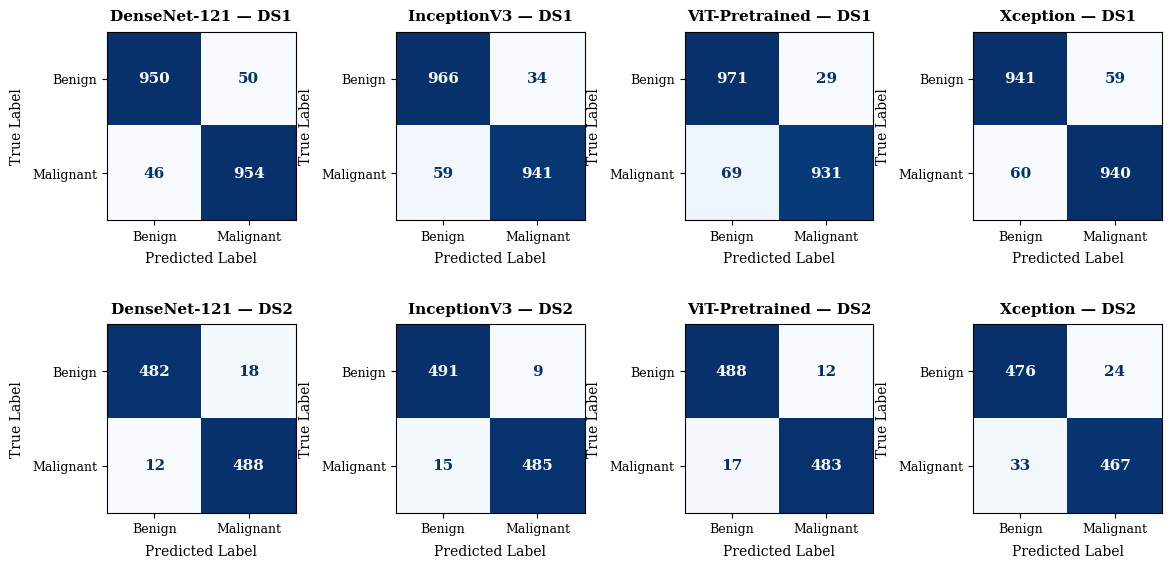

In [40]:
# Supplementary Figure: Per-Architecture Confusion Matrices (DS1 & DS2)
# Ensemble objective: OBJ-02 — 1.0 x AUC

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

ROOT   = r'D:\Tree-Structured Parzen Estimator\main'
OUTPUT = r'D:\Tree-Structured Parzen Estimator\main\ensemble_learning\ensemble_results'

MODELS = [
    {
        'name'     : 'DenseNet-121',
        'base'     : rf'{ROOT}\densenet121\full_pipeline_results',
        'probs_ds1': 'probs_ds1_densenet121.npy',
        'probs_ds2': 'probs_ds2_densenet121.npy',
    },
    {
        'name'     : 'InceptionV3',
        'base'     : rf'{ROOT}\inceptionv3\full_pipeline_results',
        'probs_ds1': 'probs_ds1_inception_v3.npy',
        'probs_ds2': 'probs_ds2_inception_v3.npy',
    },
    {
        'name'     : 'ViT-Pretrained',
        'base'     : rf'{ROOT}\vit\full_pipeline_results',
        'probs_ds1': 'probs_ds1_vit_scratch.npy',
        'probs_ds2': 'probs_ds2_vit_scratch.npy',
    },
    {
        'name'     : 'Xception',
        'base'     : rf'{ROOT}\xception\full_pipeline_results',
        'probs_ds1': 'probs_ds1_xception.npy',
        'probs_ds2': 'probs_ds2_xception.npy',
    },
]

# Publication-quality rcParams
plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 10,
    'axes.titlesize' : 11,
    'axes.labelsize' : 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

fig, axes = plt.subplots(2, 4, figsize=(11.69, 5.80))
fig.patch.set_alpha(0.0)
fig.subplots_adjust(
    left=0.06, right=0.98,
    top=0.93,  bottom=0.10,
    hspace=0.55, wspace=0.38,
)

for col, model in enumerate(MODELS):
    base = model['base']

    labels_ds1 = np.load(rf"{base}\ds1_labels.npy")
    labels_ds2 = np.load(rf"{base}\ds2_labels.npy")
    probs_ds1  = np.load(rf"{base}\{model['probs_ds1']}")
    probs_ds2  = np.load(rf"{base}\{model['probs_ds2']}")

    if probs_ds1.ndim == 2: probs_ds1 = probs_ds1[:, 1]
    if probs_ds2.ndim == 2: probs_ds2 = probs_ds2[:, 1]
    preds_ds1 = (probs_ds1 >= 0.5).astype(int)
    preds_ds2 = (probs_ds2 >= 0.5).astype(int)

    for row, (labels, preds, ds_tag) in enumerate([
        (labels_ds1, preds_ds1, 'DS1'),
        (labels_ds2, preds_ds2, 'DS2'),
    ]):
        ax = axes[row, col]
        ax.set_facecolor('none')

        cm   = confusion_matrix(labels, preds)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['Benign', 'Malignant'],
        )
        disp.plot(ax=ax, cmap='Blues', colorbar=False)

        for text in ax.texts:
            text.set_fontsize(11)
            text.set_fontweight('bold')

        ax.set_title(f"{model['name']} — {ds_tag}",
                     fontsize=11, fontweight='bold', pad=8)
        ax.set_xlabel('Predicted Label', fontsize=10, labelpad=6)
        ax.set_ylabel('True Label',      fontsize=10, labelpad=6)
        ax.tick_params(axis='both', labelsize=9)

        tn, fp, fn, tp = cm.ravel()
        print(f'[{model["name"]} | {ds_tag}]  TP={tp}  FP={fp}  FN={fn}  TN={tn}')

out_path = rf'{OUTPUT}\confusion_matrix_all_models_obj02.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', transparent=True)
print(f'\nFigure saved → {out_path}')
plt.show()
